In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [7]:
taxi_files = [filename for filename in os.listdir('data') if 'nyc_taxi' in filename]

In [8]:
taxi_files

['nyc_taxi_2020-01.csv',
 'nyc_taxi_2020-07.csv',
 'nyc_taxi_2019-07.csv',
 'nyc_taxi_2019-01.csv']

In [9]:
dataframes = []
for filename in taxi_files:
    df = pd.read_csv(
        'data/' + filename,
        usecols=[
            'tpep_pickup_datetime',
            'passenger_count',
            'trip_distance',
            'fare_amount',
            'extra',
            'mta_tax',
            'tip_amount',
            'tolls_amount',
            'improvement_surcharge',
            'total_amount',
            'congestion_surcharge'
        ],
        parse_dates=['tpep_pickup_datetime']
    )
    dataframes.append(df)

In [10]:
df = pd.concat(objs=dataframes, ignore_index=True, axis=0)
df

,tpep_pickup_datetime,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,2020-01-01 00:28:15,1.0,1.20,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5
1,2020-01-01 00:35:39,1.0,1.20,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5
2,2020-01-01 00:47:41,1.0,0.60,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5
3,2020-01-01 00:55:23,1.0,0.80,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0
4,2020-01-01 00:01:58,1.0,0.00,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0
...,...,...,...,...,...,...,...,...,...,...,...
21183626,2019-01-31 23:57:36,1.0,4.79,18.0,0.5,0.5,3.86,0.0,0.3,23.16,0.0
21183627,2019-01-31 23:32:03,1.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0
21183628,2019-01-31 23:36:36,1.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0
21183629,2019-01-31 23:14:53,1.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0


<Axes: xlabel='tpep_pickup_datetime,tpep_pickup_datetime'>

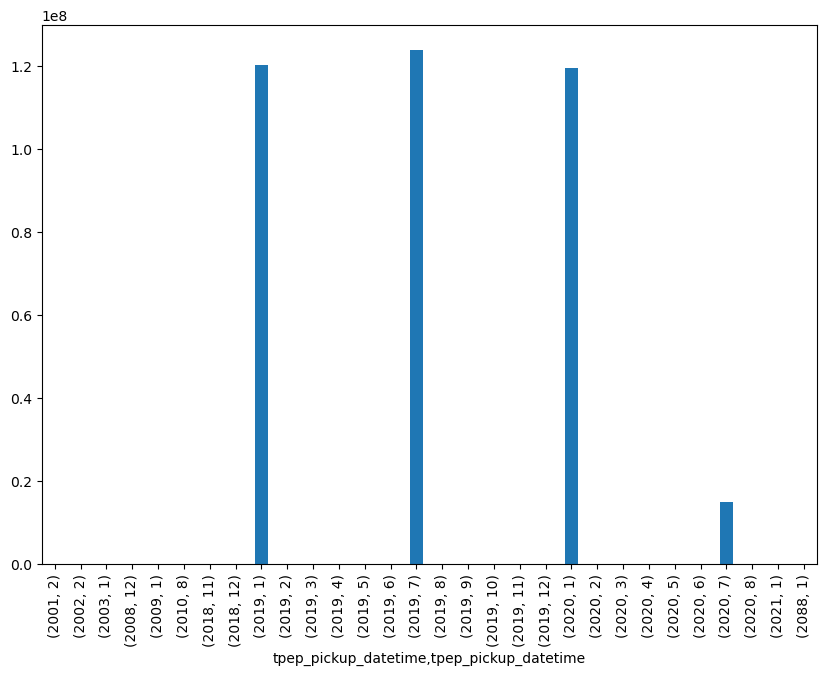

In [16]:
df.groupby(by=[df['tpep_pickup_datetime'].dt.year, df['tpep_pickup_datetime'].dt.month])['total_amount'].sum().plot.bar(figsize=(10, 7))

<Axes: xlabel='tpep_pickup_datetime,tpep_pickup_datetime'>

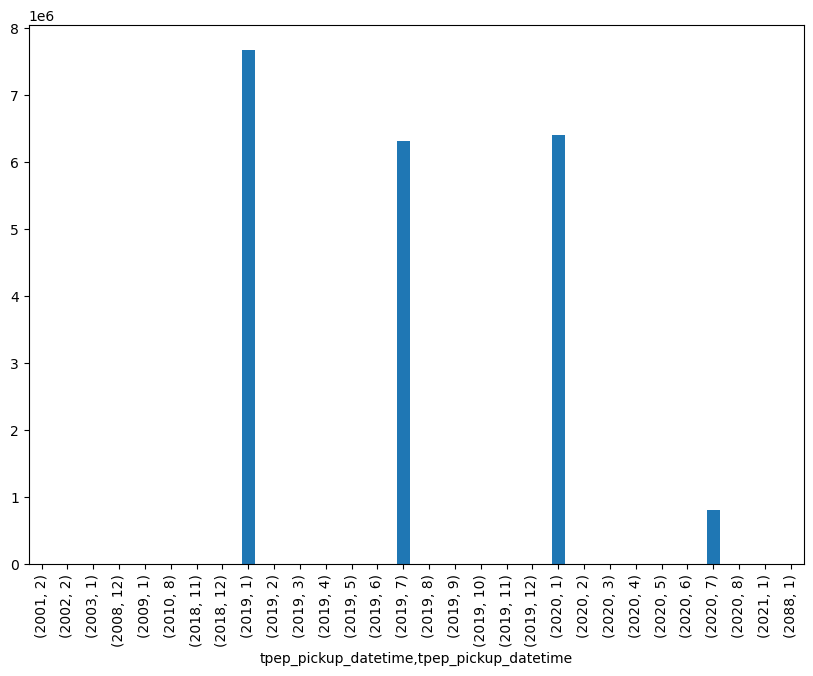

In [17]:
df.groupby(by=[df['tpep_pickup_datetime'].dt.year, df['tpep_pickup_datetime'].dt.month])['tpep_pickup_datetime'].count().plot.bar(figsize=(10, 7))

<Axes: xlabel='tpep_pickup_datetime,tpep_pickup_datetime'>

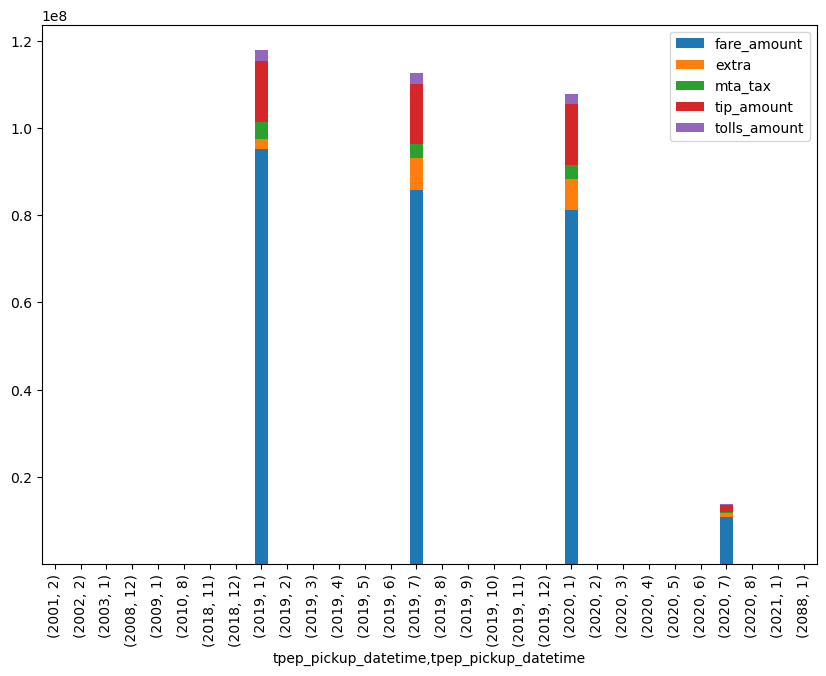

In [23]:
df.groupby(by=[df['tpep_pickup_datetime'].dt.year, df['tpep_pickup_datetime'].dt.month])[['fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount']].sum().plot.bar(stacked=True, figsize=(10, 7))

<Axes: xlabel='passenger_count'>

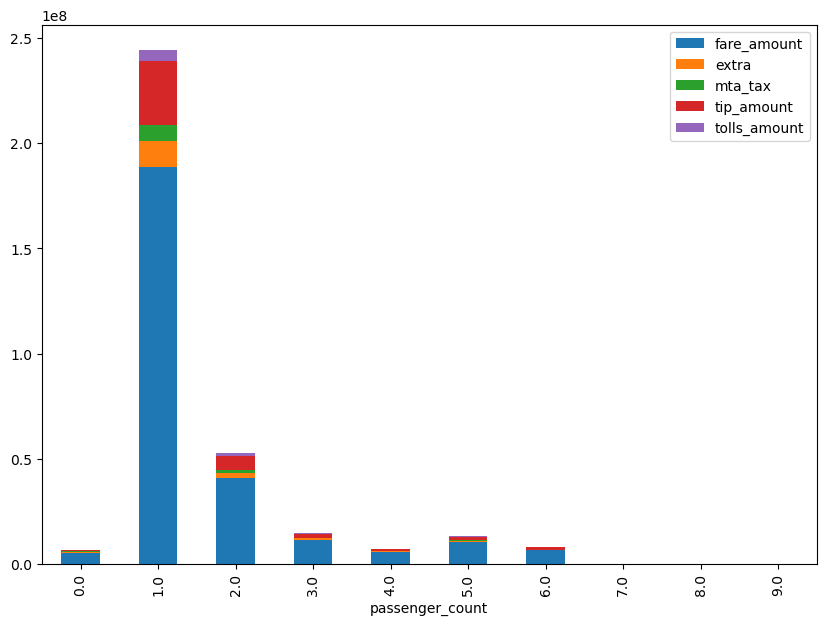

In [24]:
df.groupby(by=['passenger_count'])[['fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount']].sum().plot.bar(stacked=True, figsize=(10, 7))

In [29]:
df['tip_percentage'] = df['tip_amount'] / df['fare_amount']

In [30]:
df

,tpep_pickup_datetime,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,tip_percentage
0,2020-01-01 00:28:15,1.0,1.20,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5,0.245000
1,2020-01-01 00:35:39,1.0,1.20,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5,0.214286
2,2020-01-01 00:47:41,1.0,0.60,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5,0.166667
3,2020-01-01 00:55:23,1.0,0.80,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0,0.247273
4,2020-01-01 00:01:58,1.0,0.00,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
21183626,2019-01-31 23:57:36,1.0,4.79,18.0,0.5,0.5,3.86,0.0,0.3,23.16,0.0,0.214444
21183627,2019-01-31 23:32:03,1.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,NaN
21183628,2019-01-31 23:36:36,1.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,NaN
21183629,2019-01-31 23:14:53,1.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.00,0.0,NaN


<Axes: ylabel='Frequency'>

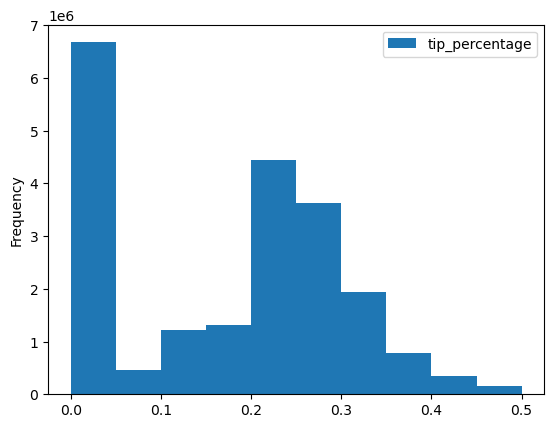

In [31]:
df.loc[(df['fare_amount'] > 0) & (df['tip_percentage'].between(0, 0.5, inclusive='both'))].plot.hist(y='tip_percentage')

In [32]:
# 45.1

In [35]:
july = df.loc[('2020-07-01' <= df['tpep_pickup_datetime']) & (df['tpep_pickup_datetime'] < '2020-08-01')]

<Axes: xlabel='tpep_pickup_datetime'>

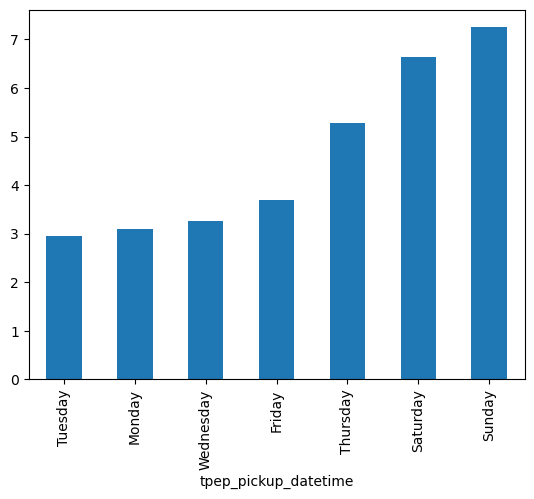

In [37]:
july.groupby(by=[july['tpep_pickup_datetime'].dt.day_name()])['trip_distance'].mean().sort_values().plot.bar()

In [38]:
# 45.2

In [40]:
july_cleaned = july.loc[(july['trip_distance'] > 0) & (july['trip_distance'] <= 500) & (july['total_amount'] > 0) & (july['total_amount'] <= 500)]

<Axes: xlabel='trip_distance', ylabel='total_amount'>

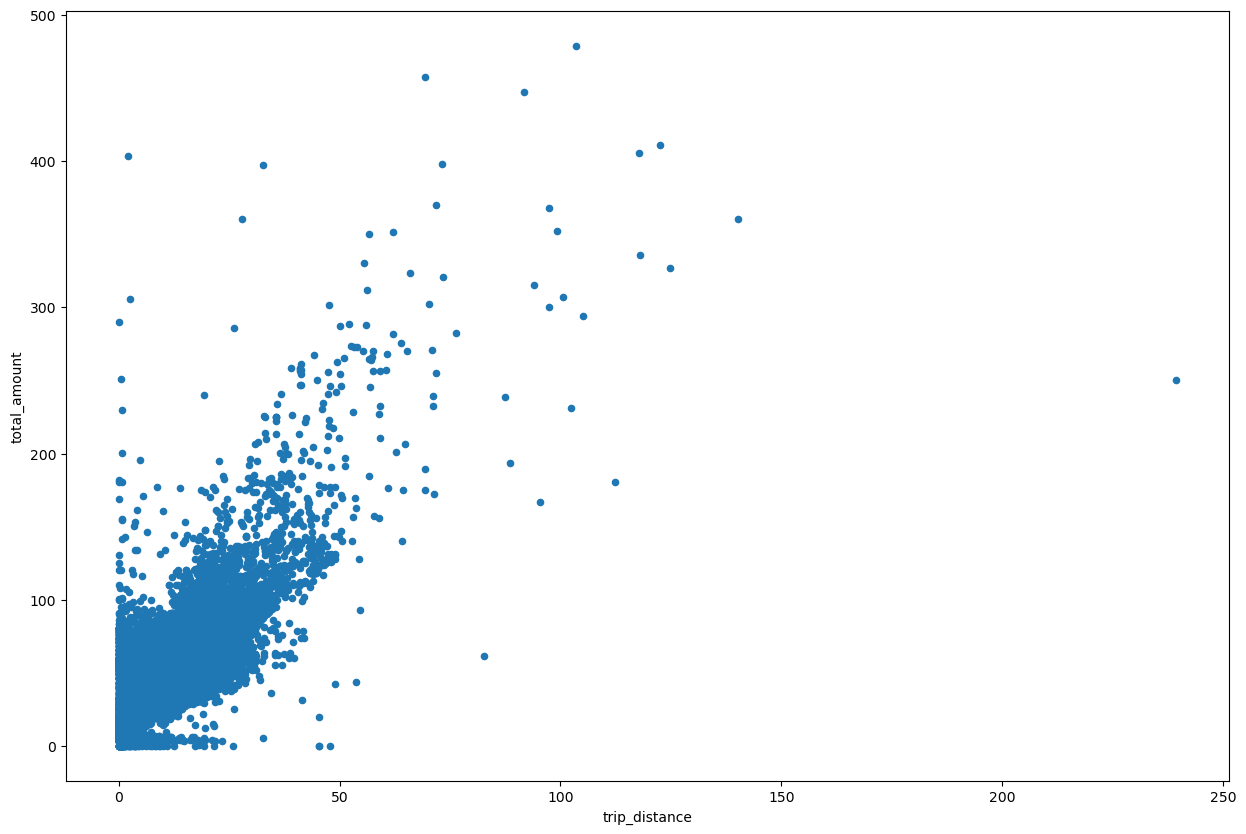

In [43]:
july_cleaned.plot.scatter(x='trip_distance', y='total_amount', figsize=(15, 10))

In [44]:
# 45.3

In [45]:
july_cleaned_v2 = july.loc[(july['trip_distance'] > 0) & (july['trip_distance'] <= 500) & (july['passenger_count'].notnull())]

<Axes: xlabel='trip_distance', ylabel='passenger_count'>

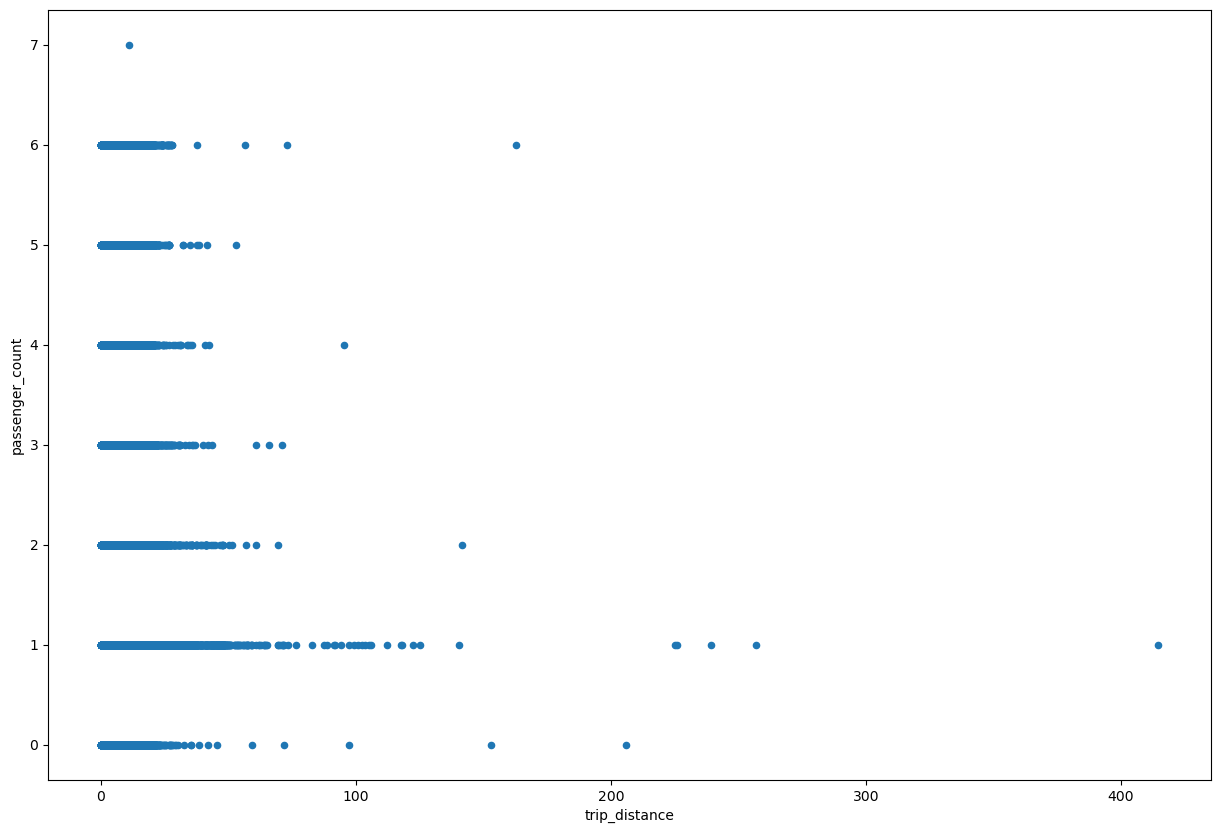

In [48]:
july_cleaned_v2.plot.scatter(x='trip_distance', y='passenger_count', figsize=(15, 10))